# EduSpark: A Big Data Framework for Student Performance Analytics
## Use Case 1 - Student Performance Analytics System

This notebook presents the final results and evaluation from the cleaned Spark analytics outputs produced for the EduSpark student performance analytics pipeline.

## Configuration

- High-performing threshold: 85
- Low-performing threshold: 60
- Fail threshold: 40
- Attendance-risk threshold: 65

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [17]:
project_root = Path.cwd()
if not (project_root / "outputs").exists() and (project_root.parent / "outputs").exists():
    project_root = project_root.parent

avg_subject_path = project_root / "outputs/analytics/average_marks_by_subject_csv"
avg_semester_path = project_root / "outputs/analytics/average_marks_by_semester_csv"
high_perf_path = project_root / "outputs/analytics/high_performing_students_csv"
low_perf_path = project_root / "outputs/analytics/low_performing_students_csv"
at_risk_path = project_root / "outputs/analytics/at_risk_students_csv"
overview_path = project_root / "outputs/analytics/analytics_overview.csv"

required_paths = [avg_subject_path, avg_semester_path, high_perf_path, low_perf_path, at_risk_path, overview_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing_list = "\n".join(str(path.relative_to(project_root)) for path in missing_paths)
    raise FileNotFoundError(
        "Analytics outputs are missing. Run scripts/generate_data.py, scripts/preprocess.py, and scripts/analytics.py first.\n"
        f"Missing:\n{missing_list}"
    )

In [18]:
def load_spark_csv_folder(folder_path):
    folder_path = Path(folder_path)
    csv_files = sorted(folder_path.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder_path}")
    return pd.read_csv(csv_files[0])

# analytics_overview.csv is written as a regular CSV file and is loaded directly with pandas.

In [19]:
avg_subject_df = load_spark_csv_folder(avg_subject_path)
avg_semester_df = load_spark_csv_folder(avg_semester_path)
high_perf_df = load_spark_csv_folder(high_perf_path)
low_perf_df = load_spark_csv_folder(low_perf_path)
at_risk_df = load_spark_csv_folder(at_risk_path)
overview_df = pd.read_csv(overview_path)

for column in ["average_mark", "student_count", "record_count"]:
    if column in avg_subject_df.columns:
        avg_subject_df[column] = pd.to_numeric(avg_subject_df[column], errors="coerce")

for column in ["year", "semester", "average_mark", "student_count", "record_count"]:
    if column in avg_semester_df.columns:
        avg_semester_df[column] = pd.to_numeric(avg_semester_df[column], errors="coerce")

for df in [high_perf_df, low_perf_df, at_risk_df]:
    for column in ["overall_average_score", "overall_attendance_percentage", "course_count", "failed_courses"]:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")

if "value" in overview_df.columns:
    overview_df["value"] = pd.to_numeric(overview_df["value"], errors="coerce")

## Data Preview

The notebook first confirms that the final output files were loaded correctly before moving into the results and evaluation sections.

In [20]:
display(overview_df)
display(avg_subject_df.head())
display(avg_semester_df.head())

,metric,value
0,total_students,10000
1,total_courses,100
2,total_grade_summary_records,239602
3,total_attendance_summary_records,239685
4,high_performing_students,2467
5,low_performing_students,4
6,at_risk_students,1381


,course_id,course_name,department,average_mark,student_count,record_count
0,COURSE98,Computer Science Course 98,Computer Science,80.70,1813,2207
1,COURSE89,Computer Science Course 89,Computer Science,80.67,1843,2173
2,COURSE56,Mathematics Course 56,Mathematics,80.62,2094,2807
3,COURSE72,Mathematics Course 72,Mathematics,80.60,2056,2815
4,COURSE62,Computer Science Course 62,Computer Science,80.54,1847,2259


,year,semester,average_mark,student_count,record_count
0,2022,1,80.15,10000,29836
1,2022,2,80.20,10000,29957
2,2023,1,80.18,10000,29804
3,2023,2,80.20,10000,30048
4,2024,1,80.22,10000,30053


## Average Marks by Subject

,course_id,course_name,department,average_mark,student_count
0,COURSE98,Computer Science Course 98,Computer Science,80.70,1813
1,COURSE89,Computer Science Course 89,Computer Science,80.67,1843
2,COURSE56,Mathematics Course 56,Mathematics,80.62,2094
3,COURSE72,Mathematics Course 72,Mathematics,80.60,2056
4,COURSE62,Computer Science Course 62,Computer Science,80.54,1847
5,COURSE5,Course 5,Mathematics,80.51,2076
6,COURSE28,Course 28,Physics,80.47,2053
7,COURSE36,Course 36,Computer Science,80.45,1877
8,COURSE75,Biology Course 75,Biology,80.45,1838
9,COURSE96,Biology Course 96,Biology,80.44,1800


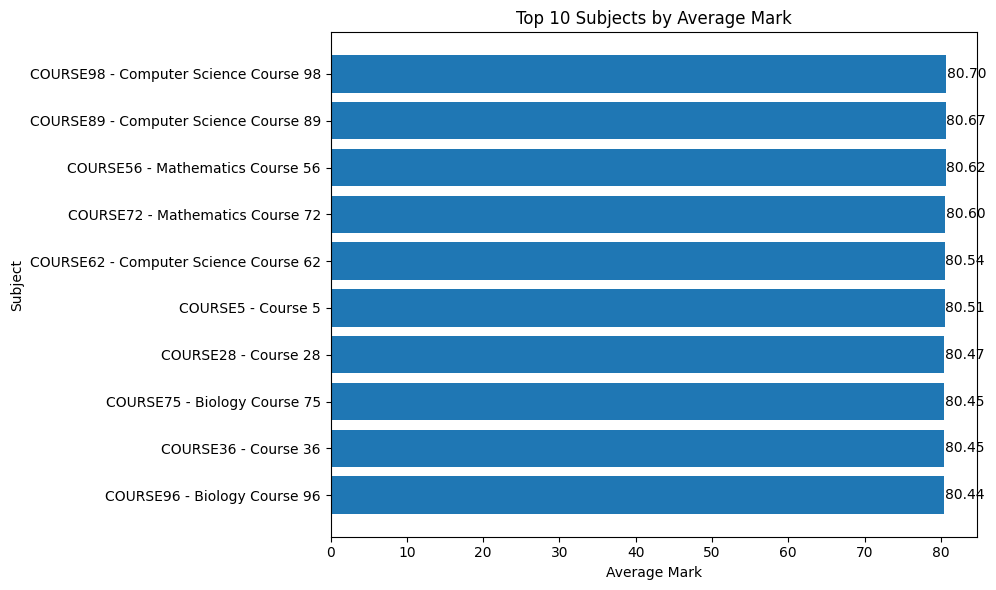

In [21]:
subject_top_10 = (
    avg_subject_df
    .sort_values("average_mark", ascending=False)
    [["course_id", "course_name", "department", "average_mark", "student_count"]]
    .head(10)
)

display(subject_top_10)

subject_chart_df = (
    subject_top_10
    .assign(subject_label=lambda df: df["course_id"] + " - " + df["course_name"])
    .sort_values("average_mark", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(subject_chart_df["subject_label"], subject_chart_df["average_mark"])
plt.xlabel("Average Mark")
plt.ylabel("Subject")
plt.title("Top 10 Subjects by Average Mark")
for index, value in enumerate(subject_chart_df["average_mark"]):
    plt.text(value + 0.05, index, f"{value:.2f}", va="center")
plt.tight_layout()
plt.show()

Computer Science and Mathematics subjects appear among the top average marks in the final outputs. This subject-level aggregation supports academic monitoring by showing where performance is strongest and where departments can compare trends over time.

## Average Marks by Semester

,year,semester,average_mark,student_count,record_count,period
0,2022,1,80.15,10000,29836,2022-S1
1,2022,2,80.20,10000,29957,2022-S2
2,2023,1,80.18,10000,29804,2023-S1
3,2023,2,80.20,10000,30048,2023-S2
4,2024,1,80.22,10000,30053,2024-S1
5,2024,2,80.16,10000,29977,2024-S2
6,2025,1,80.24,10000,29995,2025-S1
7,2025,2,80.26,10000,29932,2025-S2


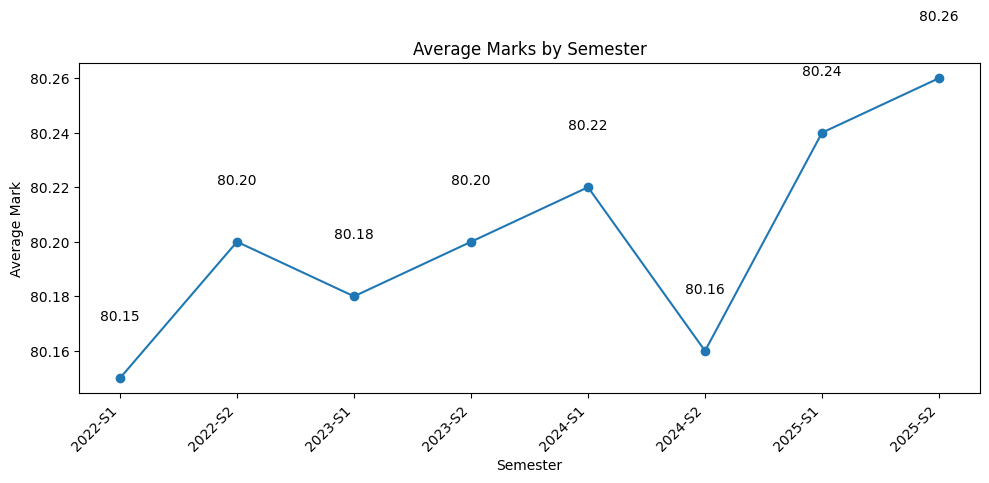

In [22]:
semester_table = (
    avg_semester_df
    .sort_values(["year", "semester"])
    [["year", "semester", "average_mark", "student_count", "record_count"]]
    .reset_index(drop=True)
)

semester_table["period"] = (
    semester_table["year"].astype(int).astype(str)
    + "-S"
    + semester_table["semester"].astype(int).astype(str)
)

display(semester_table)

plt.figure(figsize=(10, 5))
plt.plot(semester_table["period"], semester_table["average_mark"], marker="o")
plt.xlabel("Semester")
plt.ylabel("Average Mark")
plt.title("Average Marks by Semester")
for index, value in enumerate(semester_table["average_mark"]):
    plt.text(index, value + 0.02, f"{value:.2f}", ha="center", va="bottom")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Semester averages are stable across all eight periods from 2022-S1 through 2025-S2. This suggests that the overall academic performance profile remains consistent over time rather than changing sharply between cohorts.

## Student Performance Classification

,classification,count
0,High-performing students,2467
1,Low-performing students,4
2,At-risk students,1381


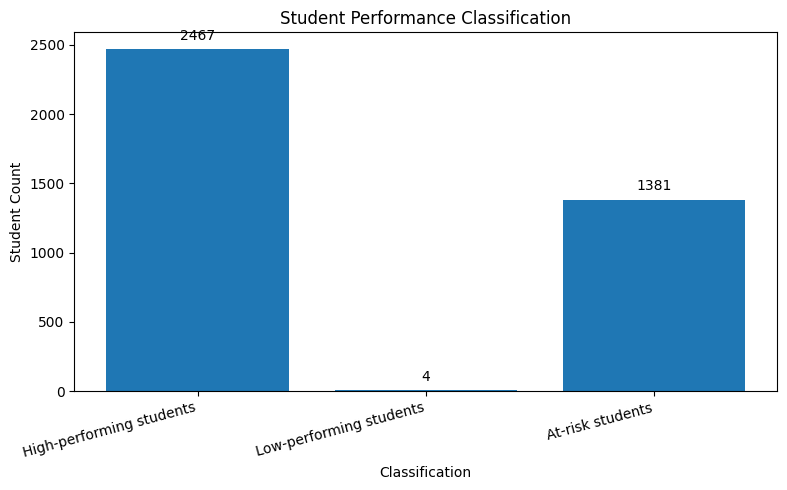

In [23]:
overview_counts = overview_df.set_index("metric")["value"].to_dict()

classification_counts = pd.DataFrame(
    {
        "classification": [
            "High-performing students",
            "Low-performing students",
            "At-risk students",
        ],
        "count": [
            int(overview_counts.get("high_performing_students", len(high_perf_df))),
            int(overview_counts.get("low_performing_students", len(low_perf_df))),
            int(overview_counts.get("at_risk_students", len(at_risk_df))),
        ],
    }
)

display(classification_counts)

plt.figure(figsize=(8, 5))
bars = plt.bar(classification_counts["classification"], classification_counts["count"])
plt.xlabel("Classification")
plt.ylabel("Student Count")
plt.title("Student Performance Classification")
plt.xticks(rotation=15, ha="right")
label_offset = classification_counts["count"].max() * 0.02
for bar, value in zip(bars, classification_counts["count"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + label_offset, f"{int(value)}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

The final counts show 2,467 high-performing students, 4 low-performing students, and 1,381 at-risk students. High-performing students form a substantial group, low-performing students are relatively few, and the at-risk population remains important for targeted intervention. The low-performing bar is small because only 4 students were classified below the final threshold.

## Top and Bottom Student Profiles

In [24]:
student_profile_columns = [
    "student_id",
    "full_name",
    "major",
    "overall_average_score",
    "overall_attendance_percentage",
    "failed_courses",
]

top_students = (
    high_perf_df
    .sort_values("overall_average_score", ascending=False)
    [student_profile_columns]
    .head(10)
)

bottom_students = (
    low_perf_df
    .sort_values("overall_average_score", ascending=True)
    [student_profile_columns]
    .head(10)
)

print("Top-performing student profiles")
display(top_students)

print("Low-performing student profiles")
display(bottom_students)

Top-performing student profiles


,student_id,full_name,major,overall_average_score,overall_attendance_percentage,failed_courses
0,10791,Naveen Gunawardena,Computer Science,95.19,79.95,0
1,8939,Sahan Jayasinghe,Computer Science,94.85,72.46,0
2,7862,Kavindi Madushanka,Biology,94.75,74.50,0
3,3043,Supun Fernando,Biology,94.39,77.20,0
4,7183,Sachini Jayasinghe,Physics,94.37,74.22,0
5,3288,Tharushi Gunawardena,Physics,94.36,80.68,0
6,9810,Naveen Abeysekera,Biology,94.24,77.97,0
7,2704,Supun Abeysekera,Biology,94.23,82.44,0
8,3079,Hiruni Jayasinghe,Computer Science,94.15,81.09,0
9,5972,Hiruni Perera,Mathematics,94.10,81.48,0


Low-performing student profiles


,student_id,full_name,major,overall_average_score,overall_attendance_percentage,failed_courses
0,10343,Sachini Dias,Biology,58.11,60.15,0
1,7036,Shehan Dias,Biology,58.68,56.86,0
2,1656,Ravindu Peiris,Mathematics,59.66,63.43,0
3,4137,Dinithi Peiris,Biology,59.99,61.11,0


Top students combine strong overall marks with generally good attendance, which reinforces their placement in the high-performing group. Low-performing cases are rare in this dataset, suggesting that the simulated distribution is weighted toward moderate to strong academic outcomes.

## Academic Risk Analysis

,student_id,full_name,major,overall_average_score,overall_attendance_percentage,failed_courses,risk_reasons
0,10343,Sachini Dias,Biology,58.11,60.15,0,Low average score; Low attendance
1,7036,Shehan Dias,Biology,58.68,56.86,0,Low average score; Low attendance
2,1656,Ravindu Peiris,Mathematics,59.66,63.43,0,Low average score; Low attendance
3,4137,Dinithi Peiris,Biology,59.99,61.11,0,Low average score; Low attendance
4,8552,Kasun Perera,Biology,60.22,59.54,1,Low attendance
5,7153,Rashmi Ekanayake,Physics,60.70,50.42,0,Low attendance
6,8086,Amal Silva,Mathematics,61.31,58.70,0,Low attendance
7,8571,Nimal Rajapaksha,Computer Science,61.58,61.54,0,Low attendance
8,7603,Chamara Gunawardena,Mathematics,61.64,63.27,0,Low attendance
9,8696,Dinithi Herath,Mathematics,61.71,58.67,0,Low attendance


,risk_factor,count
0,Low attendance,1381
1,Low average score,4
2,Multiple failed courses,1


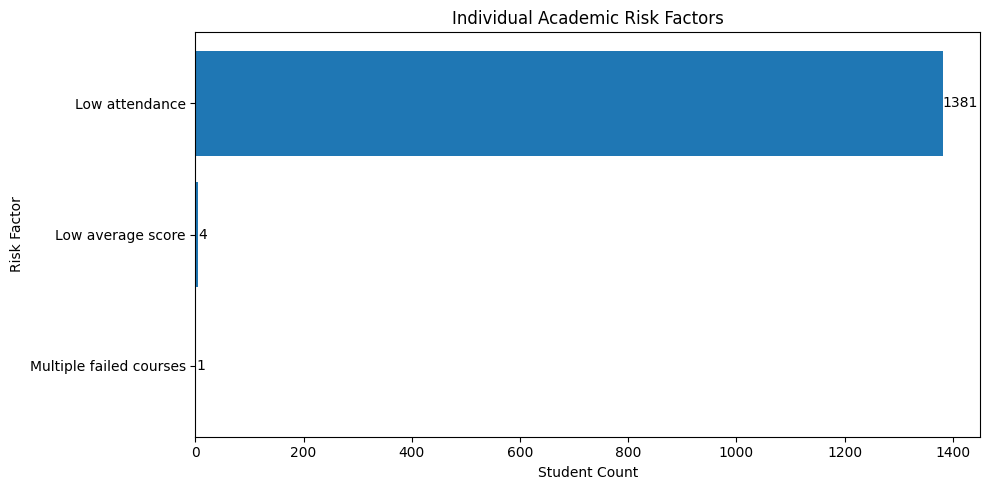

In [25]:
risk_columns = [
    "student_id",
    "full_name",
    "major",
    "overall_average_score",
    "overall_attendance_percentage",
    "failed_courses",
    "risk_reasons",
]

display(at_risk_df[risk_columns].head(10))

risk_factor_counts = (
    at_risk_df["risk_reasons"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

risk_factor_counts = (
    risk_factor_counts[risk_factor_counts != ""]
    .value_counts()
    .rename_axis("risk_factor")
    .reset_index(name="count")
)

display(risk_factor_counts)

plt.figure(figsize=(10, 5))
risk_factor_chart = risk_factor_counts.sort_values("count", ascending=True)
plt.barh(risk_factor_chart["risk_factor"], risk_factor_chart["count"])
plt.xlabel("Student Count")
plt.ylabel("Risk Factor")
plt.title("Individual Academic Risk Factors")
for index, value in enumerate(risk_factor_chart["count"]):
    plt.text(value + 0.5, index, f"{int(value)}", va="center")
plt.tight_layout()
plt.show()

Low attendance is the dominant risk factor in the final dataset, while low average score affects a smaller subset of students.

## Final Findings

- 100 subject summaries were generated.
- 8 semester summaries were generated.
- 2,467 high-performing students were identified.
- 4 low-performing students were identified.
- 1,381 at-risk students were identified.
- The system demonstrates filtering, aggregation, sorting, and joins through Spark outputs.

## Limitations

- Results come from a simulated large-scale dataset derived from a smaller base dataset.
- The generated distribution may produce relatively few low-performing students.
- Subject and semester patterns reflect the simulation assumptions used.